# Q2.3 LoRA Adapters for Sarcasm Classification across English Varieties

Mohamed Fahmi Ahmed

Train three variety-specific LoRA adapters (en-UK, en-AU, en-IN) on a frozen
LLaMA 1B base model for sarcasm classification, then evaluate cross-variety
transferability.

## Three studies in this notebook

| Study | What it does |
|-------|-------------|
| **1. Ablation** | Grid-search r ∈ {4,8,16}, lr ∈ {1e-4, 2e-4}, with/without class weights. Single variety (en-UK), 1 epoch. | 
| **2. Training** | Train 3 adapters × 2 seeds = 6 runs with the best hyperparameters. Full 3 epochs. |
| **3. Cross-variety eval** | Test each adapter on all 3 test sets → 3×3 Macro-F1 matrix. |

## References

- **Hu et al. (2021)** *LoRA: Low-Rank Adaptation of Large Language Models* 
- **Srirag et al. (2025)** *BESSTIE* , the dataset and the baseline to beat (MISTRAL 22B: F1=0.68)
- **Abercrombie & Hovy (2016)** *Putting Sarcasm Detection into Context* , justifies class weighting
- **Dettmers et al. (2023)** *QLoRA* , context on parameter-efficient fine-tuning tradeoffs

## 1. Setup

In [ ]:
# imports and project path
import os, sys, itertools, warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..") 
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Project root : /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification
PyTorch      : 2.11.0+cu130
CUDA         : True
GPU          : NVIDIA RTX A4000
VRAM         : 16.7 GB


In [ ]:
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()                           
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise RuntimeError(
        "HF_TOKEN not found. Create a .env file at project root with:\n"
    )

login(token=hf_token)
print("Authenticated with HuggingFace Hub")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated with HuggingFace Hub


In [3]:
from datasets import load_dataset
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, precision_score, recall_score,
)
from peft import PeftModel

from models.lora_adapters import (
    load_model, apply_lora, tokenize_dataset,
    training_args, save_adapter, push_adapter_to_hub,
    LoRAConfig, VARIETIES, HF_USERNAME,
)
from src.functions_to_use import class_weights, new_weighted_class

print("project modules imported")

project modules imported


## 2. Experiment configuration

SEEDS [42, 123] CW requires minimum 2 runs per experiment to demonstrate reproducibility. We use two arbitrary seeds and report mean ± std.

In [4]:
MODEL_KEY   = "llama-1b"      
TASK        = "Sarcasm"      
MAX_LENGTH  = 128
SEEDS       = [42, 123]

ADAPTER_DIR = os.path.join(PROJECT_ROOT, "adapters")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(ADAPTER_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Model      : {MODEL_KEY}")
print(f"Task       : {TASK}")
print(f"Varieties  : {VARIETIES}")
print(f"Seeds      : {SEEDS}")
print(f"Adapter dir: {ADAPTER_DIR}")

Model      : llama-1b
Task       : Sarcasm
Varieties  : ['en-UK', 'en-AU', 'en-IN']
Seeds      : [42, 123]
Adapter dir: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters


## 3. BESSTIE dataset

### Class imbalance per variety

I displayed the sarcasm distribution to highlight the data imbalance, which justifies using weighted cross-entropy, as suggested by Abercrombie & Hovy (2016).

In [5]:
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)

print("\n Sarcasm class balance (train splits)")

for variety in VARIETIES:
    split  = ds["train"].filter(lambda x: x["variety"] == variety)
    n_sarc = sum(int(x) for x in split["Sarcasm"])
    n_not  = len(split) - n_sarc
    pct    = n_sarc / len(split) * 100
    ratio  = n_not / max(n_sarc, 1)
    print(f"   {variety}: {len(split):4d} examples | "
          f"sarcastic={n_sarc:3d} ({pct:4.1f}%) | "
          f"majority:minority = {ratio:.1f}:1")

print("\nen-IN is the most imbalanced so needs the strongest class weighting.")

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})

 Sarcasm class balance (train splits)
   en-UK: 1203 examples | sarcastic= 92 ( 7.6%) | majority:minority = 12.1:1
   en-AU: 1145 examples | sarcastic=337 (29.4%) | majority:minority = 2.4:1
   en-IN: 1399 examples | sarcastic= 95 ( 6.8%) | majority:minority = 13.7:1

en-IN is the most imbalanced so needs the strongest class weighting.


## 4. Load frozen base model

We load the base model **once** and reuse it across all experiments. LoRA 
allows us to swap only the small adapter matrices
while keeping the 3B-parameter backbone in VRAM.

In [6]:
base_model, tokenizer = load_model(MODEL_KEY)
print("\nBase model loaded")

[load_model] Loading meta-llama/Llama-3.2-1B
[load_model] Set pad_token = eos_token (decoder model fix)


Loading weights: 100%|██████████| 146/146 [00:21<00:00,  6.83it/s]
LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[load_model] Loaded meta-llama/Llama-3.2-1B
[load_model] Total parameters: 1.24B

Base model loaded


## 5. Study 1: Hyperparameter ablation

Before running the full training on all 3 varieties × 2 seeds, we
need to validate our hyperparameter choices. We decided to use a small grid search on
**en-UK only** with **1 epoch** to compare:

- r ∈ {4, 8, 16}  LoRA rank (adapter capacity)
- lr ∈ {1e-4, 2e-4}  adapter learning rate
- use_weights ∈ {True, False}  class weighting for imbalance

Total: 3 × 2 × 2 = 12 configurations.

- We fix lora_alpha = 2r throughout (Hu et al. 2021's recommendation).
- We fix lora_dropout = 0.1 (PEFT default).
- We don't search over target_modules  Hu et al. Table 5 already
  established that {q, v} is optimal for accuracy/param tradeoff.

In [7]:
from transformers import Trainer

ABLATION_VARIETY = "en-UK"
ABLATION_EPOCHS  = 1              
ABLATION_BATCH   = 8

grid = list(itertools.product(
    [4, 8, 16],              # r
    [1e-4, 2e-4],            # lr
    [True, False],           # use_weights
))
print(f"Grid size: {len(grid)} configurations")

ab_train = ds["train"].filter(lambda x: x["variety"] == ABLATION_VARIETY)
ab_val   = ds["validation"].filter(lambda x: x["variety"] == ABLATION_VARIETY)
ab_weights = class_weights(ab_train, TASK)
print(f"Train: {len(ab_train)} | Val: {len(ab_val)}")
print(f"Class weights [not_sarc, sarc]: {ab_weights.tolist()}")

Grid size: 12 configurations


Filter: 100%|██████████| 313/313 [00:00<00:00, 26817.91 examples/s]


[Sarcasm] class 0 : 1111.0 samples  weight : 0.541
[Sarcasm] class 1 : 92.0 samples  weight : 6.538
Train: 1203 | Val: 101
Class weights [not_sarc, sarc]: [0.541404128074646, 6.53804349899292]


In [8]:
ablation_results = []

for r, lr, use_w in grid:
    label = f"r={r}, lr={lr}, weights={'on' if use_w else 'off'}"
    print(f"\n── {label} ──")

    cfg   = LoRAConfig(r=r, lora_alpha=r*2)
    model = apply_lora(base_model, cfg)

    train_tok = tokenize_dataset(ab_train, tokenizer, TASK, MAX_LENGTH)
    val_tok   = tokenize_dataset(ab_val,   tokenizer, TASK, MAX_LENGTH)

    args = training_args(
        output_dir = os.path.join(ADAPTER_DIR, "ablation_tmp"),
        variety    = ABLATION_VARIETY,
        seed       = 42,
        epochs     = ABLATION_EPOCHS,
        batch_size = ABLATION_BATCH,
        lr         = lr,
    )
    # disable the saving during ablation bc we don't keep these adapters.
    args.save_strategy = "no"
    args.load_best_model_at_end = False

    # pick weighted or standard trainer
    if use_w:
        TrainerCls = new_weighted_class(ab_weights)
    else:
        TrainerCls = Trainer

    trainer = TrainerCls(
        model         = model,
        args          = args,
        train_dataset = train_tok,
        eval_dataset  = val_tok,
    )
    trainer.train()

    preds   = trainer.predict(val_tok)
    y_pred  = preds.predictions.argmax(-1)
    y_true  = np.array([int(x) for x in ab_val[TASK]])
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    sarc_f1  = f1_score(y_true, y_pred, average=None)[1]
    predicts_one_class = len(set(y_pred.tolist())) == 1

    ablation_results.append({
        "r": r, "lr": lr, "use_weights": use_w,
        "macro_f1": round(macro_f1, 4),
        "sarc_f1":  round(sarc_f1, 4),
        "collapsed": predicts_one_class,
    })

    flag = "(predicts one class)" if predicts_one_class else ""
    print(f"   Macro-F1 = {macro_f1:.4f} | Sarcasm-F1 = {sarc_f1:.4f}{flag}")

print("\nAblation complete.")


── r=4, lr=0.0001, weights=on ──
trainable params: 430,080 || all params: 1,236,248,576 || trainable%: 0.0348


Map: 100%|██████████| 101/101 [00:00<00:00, 5404.96 examples/s]
`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.506551,1.258211


   Macro-F1 = 0.4767 | Sarcasm-F1 = 0.0000

── r=4, lr=0.0001, weights=off ──
trainable params: 430,080 || all params: 1,236,248,576 || trainable%: 0.0348


Epoch,Training Loss,Validation Loss
1,0.141631,0.265125


...

   Macro-F1 = 0.5478 | Sarcasm-F1 = 0.1538

── r=16, lr=0.0002, weights=on ──
trainable params: 1,708,032 || all params: 1,237,526,528 || trainable%: 0.1380


Epoch,Training Loss,Validation Loss
1,0.449585,0.635001


   Macro-F1 = 0.6606 | Sarcasm-F1 = 0.3750

── r=16, lr=0.0002, weights=off ──
trainable params: 1,708,032 || all params: 1,237,526,528 || trainable%: 0.1380


Epoch,Training Loss,Validation Loss
1,0.155217,0.226207


   Macro-F1 = 0.4712 | Sarcasm-F1 = 0.0000

Ablation complete.


In [9]:
ab_df = pd.DataFrame(ablation_results)
ab_df = ab_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)
print("Ablation results (sorted by Macro-F1)\n")
print(ab_df.to_string(index=False))

ab_df.to_csv(os.path.join(RESULTS_DIR, "ablation.csv"), index=False)
print(f"\nSaved: {RESULTS_DIR}/ablation.csv")

Ablation results (sorted by Macro-F1)

 r     lr  use_weights  macro_f1  sarc_f1  collapsed
16 0.0001         True    0.6805   0.4211      False
16 0.0002         True    0.6606   0.3750      False
 8 0.0002         True    0.6467   0.3529      False
 8 0.0001         True    0.5825   0.2353      False
 4 0.0002         True    0.5643   0.2105      False
16 0.0001        False    0.5478   0.1538      False
 4 0.0001        False    0.4794   0.0000       True
 4 0.0001         True    0.4767   0.0000      False
 4 0.0002        False    0.4740   0.0000      False
 8 0.0001        False    0.4712   0.0000      False
 8 0.0002        False    0.4712   0.0000      False
16 0.0002        False    0.4712   0.0000      False

Saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/results/ablation.csv


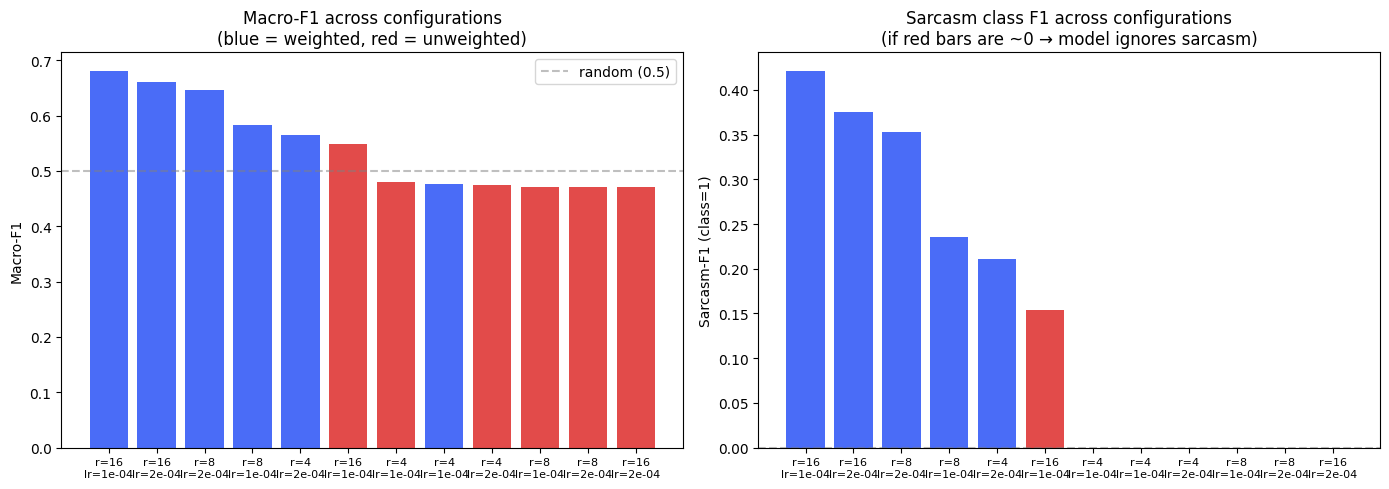

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

config_labels = [f"r={r.r}\nlr={r.lr:.0e}" for r in ab_df.itertuples()]
colors = ["#4A6CF7" if r.use_weights else "#E24B4A" for r in ab_df.itertuples()]

axes[0].bar(range(len(ab_df)), ab_df["macro_f1"], color=colors)
axes[0].set_xticks(range(len(ab_df)))
axes[0].set_xticklabels(config_labels, fontsize=8)
axes[0].axhline(0.5, linestyle="--", color="gray", alpha=0.5, label="random (0.5)")
axes[0].set_ylabel("Macro-F1")
axes[0].set_title("Macro-F1 across configurations\n(blue = weighted, red = unweighted)")
axes[0].legend()

axes[1].bar(range(len(ab_df)), ab_df["sarc_f1"], color=colors)
axes[1].set_xticks(range(len(ab_df)))
axes[1].set_xticklabels(config_labels, fontsize=8)
axes[1].axhline(0.0, linestyle="--", color="gray", alpha=0.5)
axes[1].set_ylabel("Sarcasm-F1 (class=1)")
axes[1].set_title("Sarcasm class F1 across configurations\n(if red bars are ~0 → model ignores sarcasm)")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "ablation.png"), dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# we pick the best config for Study 2

weighted_df = ab_df[ab_df["use_weights"] == True]
best = weighted_df.iloc[0]

BEST_R     = int(best["r"])
BEST_ALPHA = BEST_R * 2
BEST_LR    = float(best["lr"])

print(f" Best weighted config (for Study 2) ")
print(f"  r            = {BEST_R}")
print(f"  lora_alpha   = {BEST_ALPHA}")
print(f"  lr           = {BEST_LR}")
print(f"  Macro-F1 (ablation, 1 epoch): {best['macro_f1']:.4f}")

 Best weighted config (for Study 2) 
  r            = 16
  lora_alpha   = 32
  lr           = 0.0001
  Macro-F1 (ablation, 1 epoch): 0.6805


## 6. Study 2: Full training

Now we train 3 adapters × 2 seeds = 6 runs with the best configuration
from Study 1. Each run is 3 epochs with weighted cross-entropy.


we will save : 

For each (variety, seed) pair we save:
- The LoRA adapter to ../adapters/{variety}_seed{seed}/
- The training loss curve (for the report figures)

At the end of Study 2, the best adapter per variety (by eval loss) is
pushed to HuggingFace Hub for use in the Q5 deployment app.

In [12]:
all_train_paths = {v: {} for v in VARIETIES}
all_train_logs  = {v: {} for v in VARIETIES}

for variety in VARIETIES:
    print(f"\n{'='*60}\nTraining adapter: {variety}\n{'='*60}")

    # load and tokenise this variety's data
    v_train = ds["train"].filter(lambda x: x["variety"] == variety)
    v_val   = ds["validation"].filter(lambda x: x["variety"] == variety)
    v_weights = class_weights(v_train, TASK)
    print(f"  train: {len(v_train)} | val: {len(v_val)}")

    train_tok = tokenize_dataset(v_train, tokenizer, TASK, MAX_LENGTH)
    val_tok   = tokenize_dataset(v_val,   tokenizer, TASK, MAX_LENGTH)

    for seed in SEEDS:
        print(f"\n  ── seed {seed} ──")

        cfg   = LoRAConfig(r=BEST_R, lora_alpha=BEST_ALPHA)
        model = apply_lora(base_model, cfg)

        run_dir = os.path.join(ADAPTER_DIR, f"{variety.replace('-','_')}_seed{seed}")
        args = training_args(
            output_dir = run_dir,
            variety    = variety,
            seed       = seed,
            epochs     = 3,
            batch_size = 8,
            lr         = BEST_LR,
        )

        TrainerCls = new_weighted_class(v_weights)
        trainer = TrainerCls(
            model         = model,
            args          = args,
            train_dataset = train_tok,
            eval_dataset  = val_tok,
        )
        trainer.train()

        # save adapter (best model already loaded thanks to load_best_model_at_end)
        model.save_pretrained(run_dir)
        all_train_paths[variety][seed] = run_dir

        # keep the log history for plotting
        all_train_logs[variety][seed] = trainer.state.log_history

        print(f"  Adapter saved: {run_dir}")

print("\n✓ All 6 adapters trained.")


Training adapter: en-UK


Filter: 100%|██████████| 313/313 [00:00<00:00, 30913.82 examples/s]


[Sarcasm] class 0 : 1111.0 samples  weight : 0.541
[Sarcasm] class 1 : 92.0 samples  weight : 6.538
  train: 1203 | val: 101


Map: 100%|██████████| 101/101 [00:00<00:00, 4948.89 examples/s]



  ── seed 42 ──
trainable params: 1,708,032 || all params: 1,237,526,528 || trainable%: 0.1380


...


  ── seed 42 ──
trainable params: 1,708,032 || all params: 1,237,526,528 || trainable%: 0.1380


Epoch,Training Loss,Validation Loss
1,1.494737,0.429991
2,0.852044,1.207463
3,1.541898,0.978971


  Adapter saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters/en_IN_seed42

  ── seed 123 ──
trainable params: 1,708,032 || all params: 1,237,526,528 || trainable%: 0.1380


Epoch,Training Loss,Validation Loss
1,0.530367,1.523713
2,0.693492,1.067552
3,0.467668,1.190497


  Adapter saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/adapters/en_IN_seed123

✓ All 6 adapters trained.


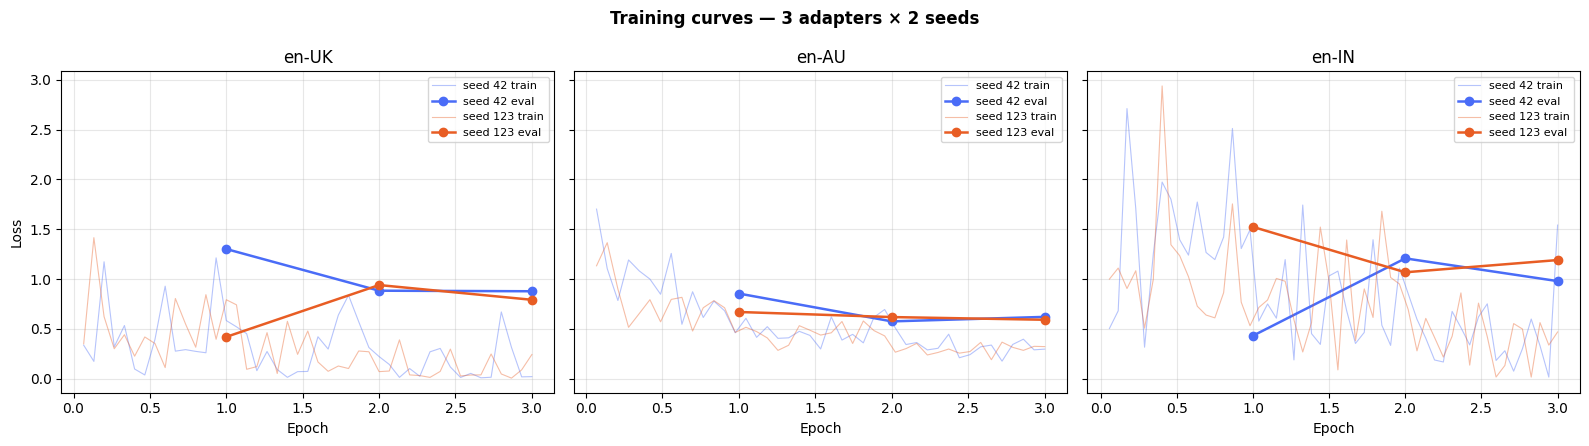

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, variety in zip(axes, VARIETIES):
    for seed, color in zip(SEEDS, ["#4A6CF7", "#E85D24"]):
        log = all_train_logs[variety][seed]
        train_steps = [e["step"] for e in log if "loss" in e and "eval_loss" not in e]
        train_loss  = [e["loss"] for e in log if "loss" in e and "eval_loss" not in e]
        eval_epochs = [e["epoch"] for e in log if "eval_loss" in e]
        eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

        if train_steps:
            max_step = max(train_steps)
            max_epoch = max(eval_epochs) if eval_epochs else 1
            train_epochs = [s / max_step * max_epoch for s in train_steps]
            ax.plot(train_epochs, train_loss, color=color, alpha=0.4, linewidth=0.8,
                    label=f"seed {seed} train")
        if eval_epochs:
            ax.plot(eval_epochs, eval_loss, color=color, marker="o", linewidth=1.8,
                    label=f"seed {seed} eval")

    ax.set_title(f"{variety}")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Loss")
fig.suptitle("Training curves — 3 adapters × 2 seeds", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# push best adapters to HuggingFace Hub (one per variety)

for variety in VARIETIES:
    adapter_path = all_train_paths[variety][42]
    model = PeftModel.from_pretrained(base_model, adapter_path)
    push_adapter_to_hub(model, tokenizer, variety, MODEL_KEY)
    print()

print("Adapters pushed to HuggingFace Hub.")

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-uk-llama-1b...


Processing Files (1 / 1): 100%|██████████| 6.84MB / 6.84MB, 4.27MB/s  
New Data Upload: 100%|██████████| 6.84MB / 6.84MB, 4.27MB/s  
Processing Files (1 / 1): 100%|██████████| 17.2MB / 17.2MB, 28.7MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-uk-llama-1b')

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-au-llama-1b...


Processing Files (1 / 1): 100%|██████████| 6.84MB / 6.84MB,  467kB/s  
New Data Upload: 100%|██████████| 6.84MB / 6.84MB,  467kB/s  
Processing Files (1 / 1): 100%|██████████| 17.2MB / 17.2MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-au-llama-1b')

[push_adapter_to_hub] Pushing to momofahmi/besstie-lora-en-in-llama-1b...


Processing Files (1 / 1): 100%|██████████| 6.84MB / 6.84MB, 2.07MB/s  
New Data Upload: 100%|██████████| 6.84MB / 6.84MB, 2.07MB/s  
Processing Files (1 / 1): 100%|██████████| 17.2MB / 17.2MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


[push_adapter_to_hub] Done — load with:
  PeftModel.from_pretrained(base_model, 'momofahmi/besstie-lora-en-in-llama-1b')

Adapters pushed to HuggingFace Hub.


## 7. Study 3: Cross-variety evaluation

We will evaluate each of the 3 adapters
on each of the 3 test sets : 3×3 matrix of Macro-F1 scores.

In [15]:
def predict(adapter_path, base_model, tokenizer, test_ds, max_len=128):
    """Run inference with a given adapter on a given test split."""
    peft_model = PeftModel.from_pretrained(base_model, adapter_path)
    peft_model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    peft_model = peft_model.to(device)

    if torch.cuda.is_available():
        peft_model = peft_model.half()

    y_true, y_pred = [], []
    texts  = list(test_ds["text"])
    labels = list(test_ds[TASK])

    for i in range(0, len(texts), 16):
        batch = tokenizer(
            texts[i:i+16],
            truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            preds = peft_model(**batch).logits.argmax(-1).cpu().tolist()
        y_true.extend([int(l) for l in labels[i:i+16]])
        y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

In [16]:
# run cross-variety evaluation 

all_eval = {train_v: {test_v: {} for test_v in VARIETIES} for train_v in VARIETIES}

for train_v in VARIETIES:
    print(f"\n Adapter trained on {train_v} ")
    for test_v in VARIETIES:
        test_split = ds["test"].filter(lambda x: x["variety"] == test_v)
        print(f"   Evaluating on {test_v} ({len(test_split)} examples)")

        for seed in SEEDS:
            path = all_train_paths[train_v][seed]
            y_true, y_pred = predict(path, base_model, tokenizer, test_split, MAX_LENGTH)

            # Warn if the model collapses to a single class
            if len(set(y_pred.tolist())) == 1:
                print(f" seed {seed}: predicts only one class")

            all_eval[train_v][test_v][seed] = {
                "y_true":    y_true,
                "y_pred":    y_pred,
                "macro_f1":  round(f1_score(y_true, y_pred, average="macro"), 4),
                "precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
                "recall":    round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
                "f1_class0": round(f1_score(y_true, y_pred, average=None, zero_division=0)[0], 4),
                "f1_class1": round(f1_score(y_true, y_pred, average=None, zero_division=0)[1], 4),
                "report":    classification_report(y_true, y_pred,
                                target_names=["Not Sarcastic", "Sarcastic"],
                                digits=4, zero_division=0),
            }

print("\n Cross-variety evaluation complete.")


 Adapter trained on en-UK 


Filter: 100%|██████████| 2183/2183 [00:00<00:00, 121791.53 examples/s]

   Evaluating on en-UK (700 examples)



Filter: 100%|██████████| 2183/2183 [00:00<00:00, 146540.85 examples/s]


   Evaluating on en-AU (667 examples)


Filter: 100%|██████████| 2183/2183 [00:00<00:00, 139567.19 examples/s]


   Evaluating on en-IN (816 examples)

 Adapter trained on en-AU 
   Evaluating on en-UK (700 examples)
   Evaluating on en-AU (667 examples)
   Evaluating on en-IN (816 examples)

 Adapter trained on en-IN 
   Evaluating on en-UK (700 examples)
   Evaluating on en-AU (667 examples)
   Evaluating on en-IN (816 examples)

 Cross-variety evaluation complete.


In [17]:
# average across seeds and build result matrices
avg = {tv: {tv2: {} for tv2 in VARIETIES} for tv in VARIETIES}

for tv in VARIETIES:
    for tv2 in VARIETIES:
        r1 = all_eval[tv][tv2][42]
        r2 = all_eval[tv][tv2][123]
        for key in ["macro_f1", "precision", "recall", "f1_class0", "f1_class1"]:
            v1, v2 = r1[key], r2[key]
            avg[tv][tv2][f"{key}_mean"] = round((v1 + v2) / 2, 4)
            avg[tv][tv2][f"{key}_std"]  = round(abs(v1 - v2) / 2, 4)

# build the key matrices
def build_matrix(key):
    m = pd.DataFrame(index=VARIETIES, columns=VARIETIES, dtype=float)
    for tv in VARIETIES:
        for tv2 in VARIETIES:
            m.loc[tv, tv2] = avg[tv][tv2][key]
    m.index.name, m.columns.name = "Trained on", "Tested on"
    return m

matrix_macro = build_matrix("macro_f1_mean")
matrix_sarc  = build_matrix("f1_class1_mean")

print(" Macro-F1 (mean of 2 seeds) ")
print(matrix_macro.to_string(float_format="{:.4f}".format))
print("\n Sarcasm class F1 (mean of 2 seeds) ")
print(matrix_sarc.to_string(float_format="{:.4f}".format))

 Macro-F1 (mean of 2 seeds) 
Tested on   en-UK  en-AU  en-IN
Trained on                     
en-UK      0.6772 0.5202 0.5823
en-AU      0.6139 0.7359 0.5293
en-IN      0.6751 0.5558 0.5942

 Sarcasm class F1 (mean of 2 seeds) 
Tested on   en-UK  en-AU  en-IN
Trained on                     
en-UK      0.4018 0.2188 0.2354
en-AU      0.3717 0.6444 0.2462
en-IN      0.4018 0.2826 0.2406


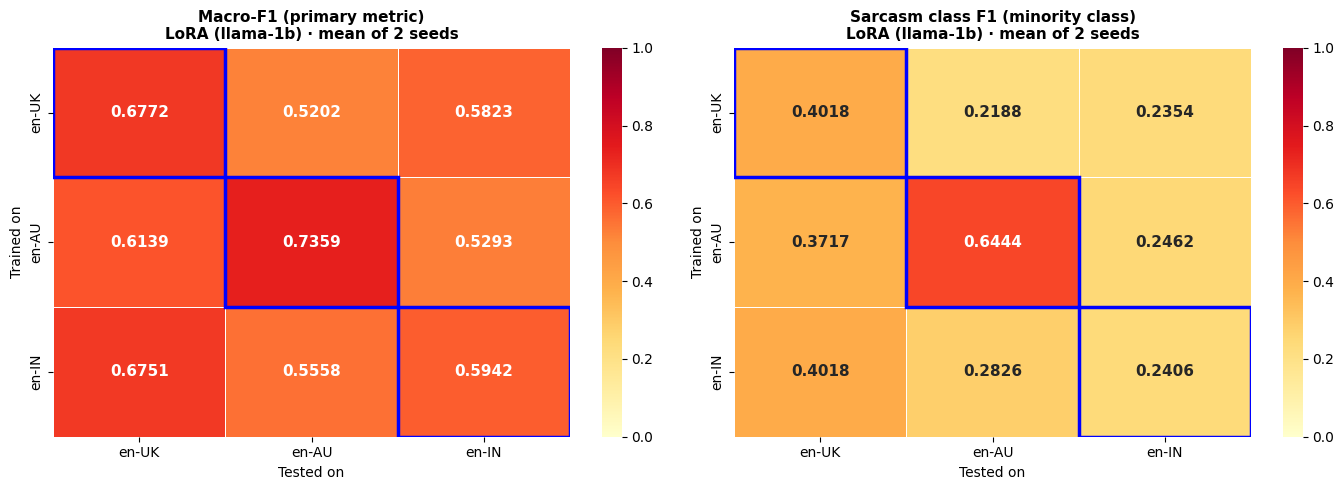

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, m, title in zip(
    axes, [matrix_macro, matrix_sarc],
    ["Macro-F1 (primary metric)", "Sarcasm class F1 (minority class)"]
):
    sns.heatmap(
        m.astype(float), annot=True, fmt=".4f",
        cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.5, ax=ax,
        annot_kws={"size": 11, "weight": "bold"},
    )
    ax.set_title(f"{title}\nLoRA ({MODEL_KEY}) · mean of 2 seeds",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Tested on")
    ax.set_ylabel("Trained on")
    for i in range(len(VARIETIES)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="blue", lw=2.5))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cross_variety_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

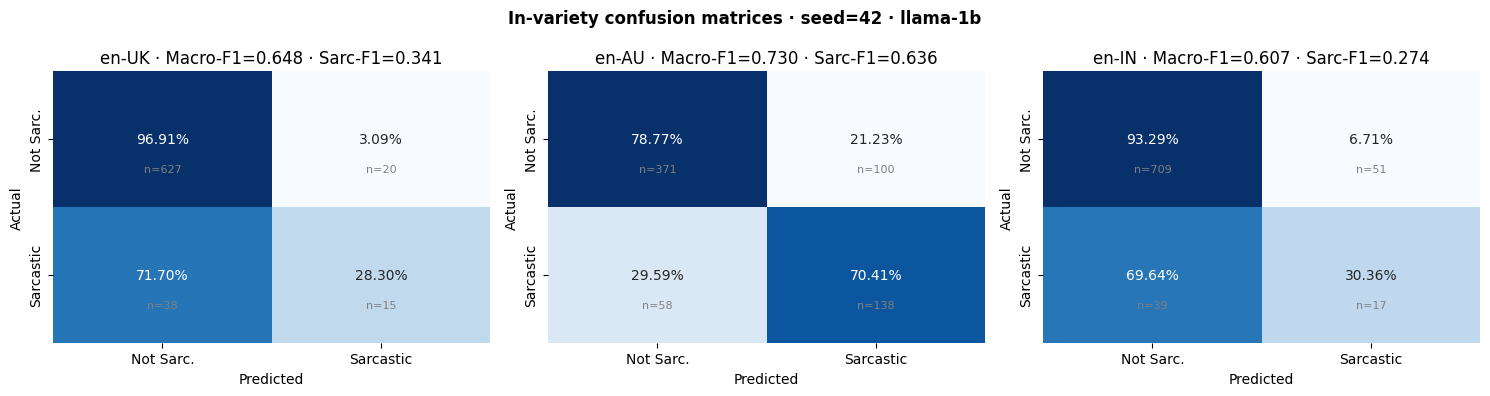

In [19]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"In-variety confusion matrices · seed=42 · {MODEL_KEY}",
             fontweight="bold", fontsize=12)

for ax, variety in zip(axes, VARIETIES):
    data = all_eval[variety][variety][42]
    cm = confusion_matrix(data["y_true"], data["y_pred"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2%", cmap="Blues",
        xticklabels=["Not Sarc.", "Sarcastic"],
        yticklabels=["Not Sarc.", "Sarcastic"],
        ax=ax, cbar=False,
    )
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.72, f"n={cm[i,j]}",
                    ha="center", va="center", fontsize=8, color="gray")

    f1 = all_eval[variety][variety][42]["macro_f1"]
    sc = all_eval[variety][variety][42]["f1_class1"]
    ax.set_title(f"{variety} · Macro-F1={f1:.3f} · Sarc-F1={sc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Export results for the report

In [20]:
rows = []
for tv in VARIETIES:
    for tv2 in VARIETIES:
        rec = {"trained_on": tv, "tested_on": tv2}
        rec.update(avg[tv][tv2])
        rows.append(rec)

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(RESULTS_DIR, "cross_variety_results.csv"), index=False)
print(f"Saved: {RESULTS_DIR}/cross_variety_results.csv")
print(results_df.to_string(index=False))

Saved: /user/HS401/mf01425/Documents/coursework nlp/NLP-sequence-classification/results/cross_variety_results.csv
trained_on tested_on  macro_f1_mean  macro_f1_std  precision_mean  precision_std  recall_mean  recall_std  f1_class0_mean  f1_class0_std  f1_class1_mean  f1_class1_std
     en-UK     en-UK         0.6772        0.0288          0.6859         0.0002       0.6796      0.0535          0.9525         0.0033          0.4018         0.0610
     en-UK     en-AU         0.5202        0.0160          0.6320         0.0211       0.5436      0.0060          0.8216         0.0060          0.2188         0.0378
     en-UK     en-IN         0.5823        0.0151          0.5774         0.0201       0.5998      0.0024          0.9291         0.0156          0.2354         0.0145
     en-AU     en-UK         0.6139        0.0023          0.6120         0.0017       0.8343      0.0051          0.8560         0.0009          0.3717         0.0038
     en-AU     en-AU         0.7359        0.0

In [21]:
for variety in VARIETIES:
    print(f"\n {variety} (in-variety, seed=42)")
    print(all_eval[variety][variety][42]["report"])


 en-UK (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.9429    0.9691    0.9558       647
    Sarcastic     0.4286    0.2830    0.3409        53

     accuracy                         0.9171       700
    macro avg     0.6857    0.6261    0.6484       700
 weighted avg     0.9039    0.9171    0.9092       700


 en-AU (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.8648    0.7877    0.8244       471
    Sarcastic     0.5798    0.7041    0.6359       196

     accuracy                         0.7631       667
    macro avg     0.7223    0.7459    0.7302       667
 weighted avg     0.7811    0.7631    0.7691       667


 en-IN (in-variety, seed=42)
               precision    recall  f1-score   support

Not Sarcastic     0.9479    0.9329    0.9403       760
    Sarcastic     0.2500    0.3036    0.2742        56

     accuracy                         0.8897       816
    macro avg     0.59